In [1]:
# Import the data analysis library
import pandas as pd

# The exact path to your folder in Google Drive
path = '/content/drive/MyDrive/olist_project/'

# Load the 5 required CSV files
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
translation = pd.read_csv(path + 'product_category_name_translation.csv')

# Let's check if it worked!
print("✅ All files loaded successfully!")
print("Orders shape:", orders.shape)
print("Reviews shape:", reviews.shape)
print("Customers shape:", customers.shape)
print("Products shape:", products.shape)
print("Translation shape:", translation.shape)

✅ All files loaded successfully!
Orders shape: (99441, 8)
Reviews shape: (99224, 7)
Customers shape: (99441, 5)
Products shape: (32951, 9)
Translation shape: (71, 2)


In [2]:
# ==========================================
# STORY 1: THE SCHEMA BUILDER
# ==========================================

# 1. Join Orders and Reviews on 'order_id'
# We use 'left' join so we keep all orders, even if they don't have a review
master_df = orders.merge(reviews, on='order_id', how='left')

# CRITICAL FIX: Drop duplicate reviews for the same order (keep the last one submitted)
master_df = master_df.drop_duplicates(subset='order_id', keep='last')

# 2. Join Customers on 'customer_id'
master_df = master_df.merge(customers, on='customer_id', how='left')

# 3. Let's check the shape!
print("✅ Master Dataset Created!")
print("Master shape:", master_df.shape)

# Let's also look at the columns we now have access to:
print("\nColumns in our Master Dataset:")
print(master_df.columns.tolist())

✅ Master Dataset Created!
Master shape: (99441, 18)

Columns in our Master Dataset:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [3]:
# ==========================================
# STORY 2: THE "REAL" DELAY CALCULATOR
# ==========================================

# 1. Keep ONLY delivered orders (exclude canceled/unavailable)
delivered_df = master_df[master_df['order_status'] == 'delivered'].copy()

# 2. Convert text dates to actual Python datetime objects
delivered_df['order_estimated_delivery_date'] = pd.to_datetime(delivered_df['order_estimated_delivery_date'])
delivered_df['order_delivered_customer_date'] = pd.to_datetime(delivered_df['order_delivered_customer_date'])

# 3. Calculate the difference in days
# Formula: Estimated - Actual
# If positive = early/on time. If negative = late.
delivered_df['Days_Difference'] = (delivered_df['order_estimated_delivery_date'] - delivered_df['order_delivered_customer_date']).dt.days

# 4. Classify into statuses
def classify_delay(days):
    if days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

delivered_df['Delivery_Status'] = delivered_df['Days_Difference'].apply(classify_delay)

# 5. Check the results!
print("✅ Delay Calculation Complete!")
print(f"Total delivered orders analyzed: {len(delivered_df)}\n")

print("Order Breakdown:")
print(delivered_df['Delivery_Status'].value_counts())

print("\nAverage Review Score by Delivery Status:")
print(delivered_df.groupby('Delivery_Status')['review_score'].mean())

✅ Delay Calculation Complete!
Total delivered orders analyzed: 96478

Order Breakdown:
Delivery_Status
On Time       88644
Super Late     4219
Late           3615
Name: count, dtype: int64

Average Review Score by Delivery Status:
Delivery_Status
Late          3.463004
On Time       4.294069
Super Late    1.792246
Name: review_score, dtype: float64


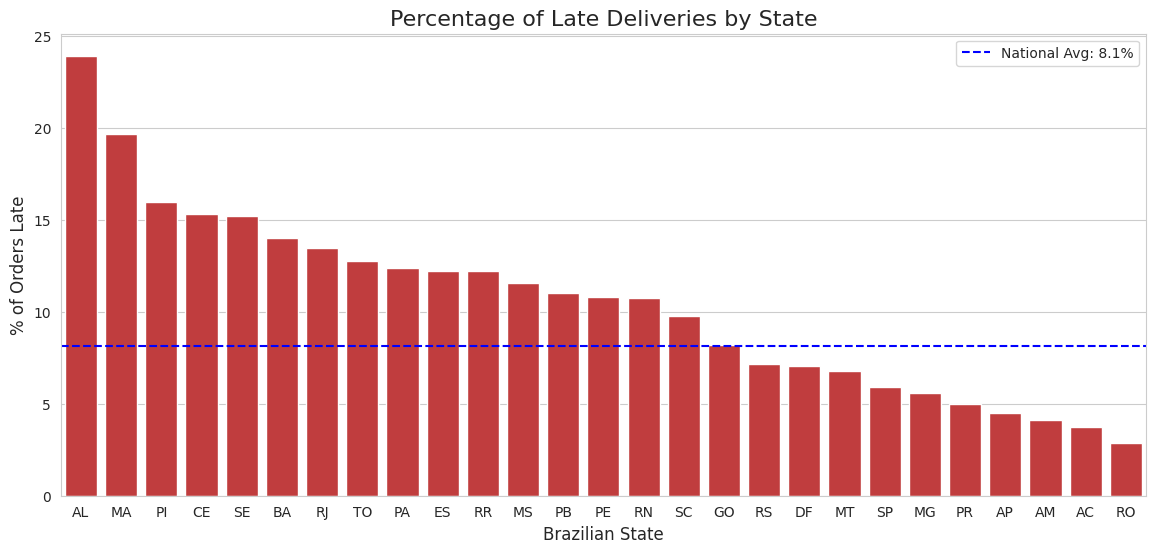


🏆 Top 5 Worst Performing States:
customer_state  total_orders  pct_late
            AL           397 23.929471
            MA           717 19.665272
            PI           476 15.966387
            CE          1279 15.324472
            SE           335 15.223881


In [4]:
# ==========================================
# STORY 3: THE GEOGRAPHIC HEATMAP (BAR CHART)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart size and style
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# 1. Create a flag for ANY late order (Late + Super Late)
delivered_df['Is_Late'] = delivered_df['Delivery_Status'].isin(['Late', 'Super Late'])

# 2. Group by State and calculate totals
state_stats = delivered_df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('Is_Late', 'sum')
).reset_index()

# 3. Calculate % Late
state_stats['pct_late'] = (state_stats['late_orders'] / state_stats['total_orders']) * 100

# 4. Sort states from worst to best
worst_states = state_stats.sort_values(by='pct_late', ascending=False)

# 5. Draw the bar chart
sns.barplot(data=worst_states, x='customer_state', y='pct_late', color='#d62728')

# Add a line for the National Average
national_avg = delivered_df['Is_Late'].mean() * 100
plt.axhline(y=national_avg, color='blue', linestyle='--', label=f'National Avg: {national_avg:.1f}%')

plt.title('Percentage of Late Deliveries by State', fontsize=16)
plt.xlabel('Brazilian State', fontsize=12)
plt.ylabel('% of Orders Late', fontsize=12)
plt.legend()
plt.show()

# Print the exact numbers for the worst 5 states
print("\n🏆 Top 5 Worst Performing States:")
print(worst_states[['customer_state', 'total_orders', 'pct_late']].head().to_string(index=False))

/tmp/ipykernel_16830/3514726506.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_scores.index, y=status_scores.values, ax=axes[0], palette=colors)


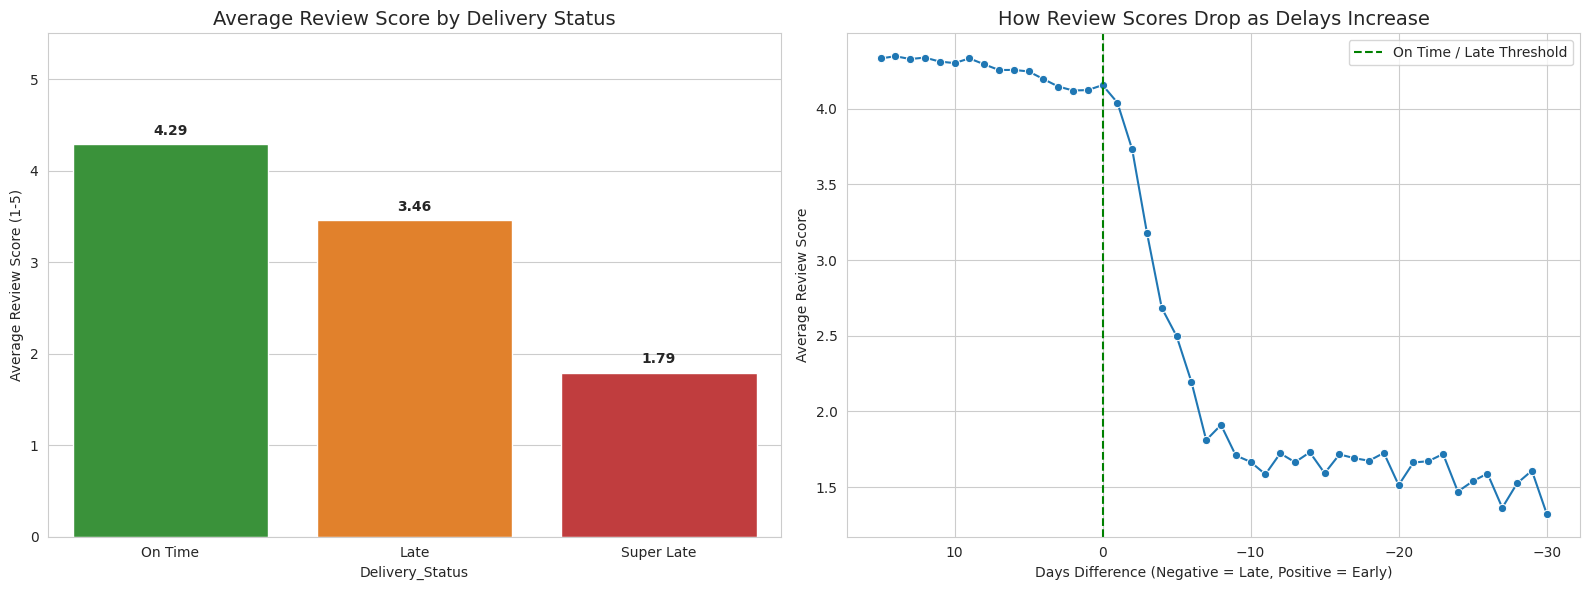

In [5]:
# ==========================================
# STORY 4: THE SENTIMENT CORRELATION
# ==========================================

# Set up a side-by-side chart layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- CHART 1: Average Score by Status ---
status_scores = delivered_df.groupby('Delivery_Status')['review_score'].mean().reindex(['On Time', 'Late', 'Super Late'])
colors = ['#2ca02c', '#ff7f0e', '#d62728'] # Green, Orange, Red

sns.barplot(x=status_scores.index, y=status_scores.values, ax=axes[0], palette=colors)
axes[0].set_title('Average Review Score by Delivery Status', fontsize=14)
axes[0].set_ylabel('Average Review Score (1-5)')
axes[0].set_ylim(0, 5.5)

# Add numbers on top of the bars
for i, v in enumerate(status_scores.values):
    axes[0].text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

# --- CHART 2: Delay Days vs Review Score Trend ---
# Calculate the average review score for every single day of delay
delay_trend = delivered_df.groupby('Days_Difference')['review_score'].mean().reset_index()

# Keep it clean: only show delays between -30 days and +15 days early
trend_filtered = delay_trend[(delay_trend['Days_Difference'] >= -30) & (delay_trend['Days_Difference'] <= 15)]

sns.lineplot(data=trend_filtered, x='Days_Difference', y='review_score', ax=axes[1], color='#1f77b4', marker='o')
axes[1].axvline(x=0, color='green', linestyle='--', label='On Time / Late Threshold')
axes[1].set_title('How Review Scores Drop as Delays Increase', fontsize=14)
axes[1].set_xlabel('Days Difference (Negative = Late, Positive = Early)')
axes[1].set_ylabel('Average Review Score')
axes[1].invert_xaxis() # Flips it so "Late" is on the right, easier to read!
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_16830/1879855362.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=valid_cats.head(10), x='pct_late', y='product_category_name_english', palette='Reds_r')


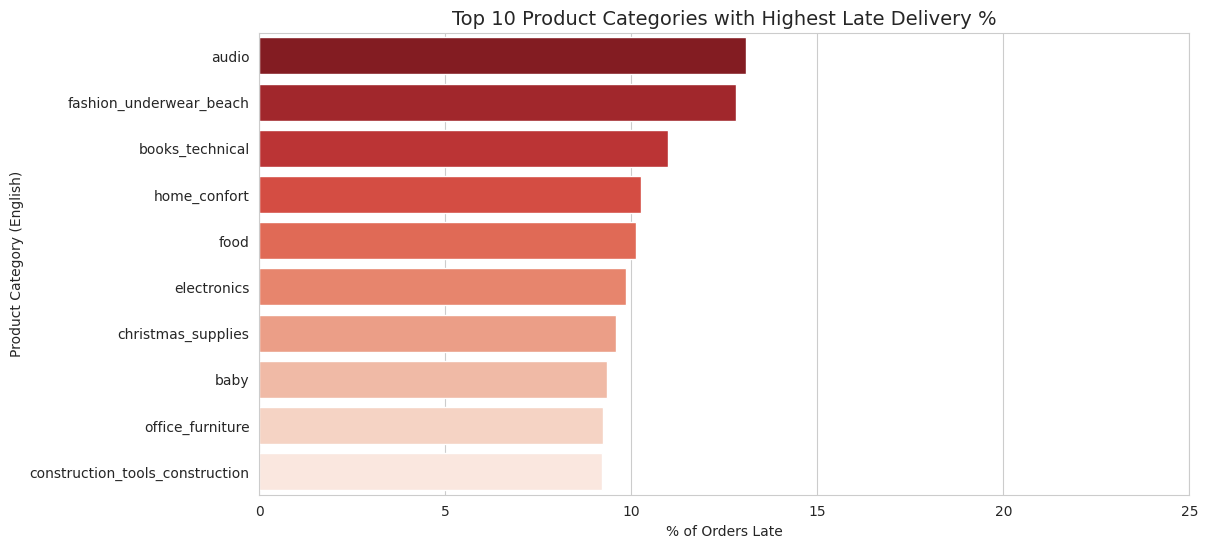


🔍 CEO'S SPECIFIC QUESTION: Furniture vs Electronics
furniture_living_room: 8.6% late (409 orders)
furniture_bedroom: 7.9% late (89 orders)
furniture_mattress_and_upholstery: 13.5% late (37 orders)
computers: 6.8% late (176 orders)
electronics: 9.9% late (2507 orders)


In [6]:
# ==========================================
# BONUS STORY: THE TRANSLATION CHALLENGE
# ==========================================

# 1. Load the items table (links orders to products)
items = pd.read_csv(path + 'olist_order_items_dataset.csv')

# 2. Chain the joins: Items -> Products -> English Translation
cat_df = items.merge(products, on='product_id', how='left')
cat_df = cat_df.merge(translation, on='product_category_name', how='left')

# 3. Attach English categories to our delivered orders
order_cats = delivered_df[['order_id', 'Delivery_Status']].merge(
    cat_df[['order_id', 'product_category_name_english']],
    on='order_id',
    how='left'
)

# Drop duplicates (in case an order had multiple of the same category)
order_cats = order_cats.drop_duplicates(subset='order_id')

# 4. Calculate % Late per English Category
order_cats['Is_Late'] = order_cats['Delivery_Status'].isin(['Late', 'Super Late'])
cat_stats = order_cats.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'count'),
    late_orders=('Is_Late', 'sum')
).reset_index()

cat_stats['pct_late'] = (cat_stats['late_orders'] / cat_stats['total_orders']) * 100

# 5. Filter out tiny categories (less than 50 orders) for accuracy
valid_cats = cat_stats[cat_stats['total_orders'] >= 50].sort_values(by='pct_late', ascending=False)

# 6. Plot the Top 10 Worst Categories
plt.figure(figsize=(12, 6))
sns.barplot(data=valid_cats.head(10), x='pct_late', y='product_category_name_english', palette='Reds_r')
plt.title('Top 10 Product Categories with Highest Late Delivery %', fontsize=14)
plt.xlabel('% of Orders Late')
plt.ylabel('Product Category (English)')
plt.xlim(0, 25)

plt.show()

# Print the specific categories the CEO asked about
print("\n🔍 CEO'S SPECIFIC QUESTION: Furniture vs Electronics")
check_cats = ['furniture_living_room', 'furniture_bedroom', 'furniture_mattress_and_upholstery', 'computers', 'electronics']
for cat in check_cats:
    row = cat_stats[cat_stats['product_category_name_english'] == cat]
    if not row.empty:
        print(f"{cat}: {row['pct_late'].values[0]:.1f}% late ({int(row['total_orders'].values[0])} orders)")

/tmp/ipykernel_16830/401214454.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=handoff_stats.index, y=handoff_stats.values, ax=ax, palette=colors)


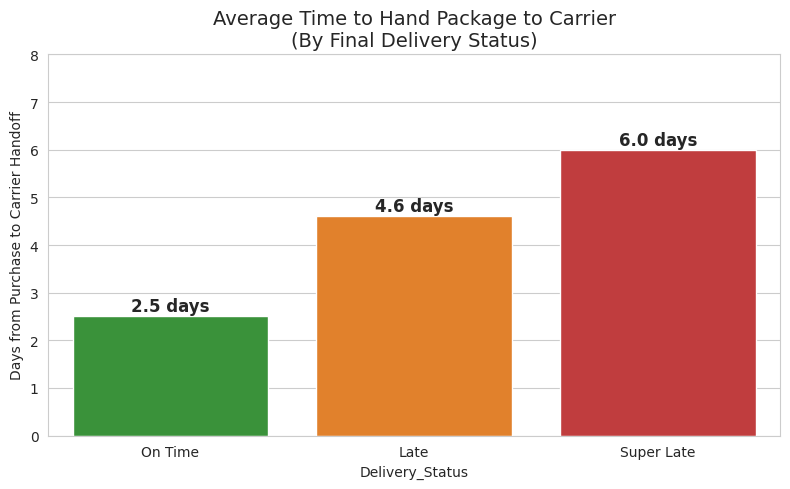

💡 BUSINESS INSIGHT FOR THE CEO:
- On Time packages took an average of 2.5 days to leave our warehouse.
- Super Late packages took an average of 6.0 days to leave our warehouse.

Conclusion: A delayed handoff to the carrier is a strong predictor of a late final delivery.
We must investigate our internal packing and shipping workflows.


In [7]:
# ==========================================
# CANDIDATE'S CHOICE: THE CARRIER HANDOFF BOTTLENECK
# ==========================================

# Make a copy to avoid warnings
handoff_df = delivered_df.copy()

# Convert the relevant timestamps to actual dates
handoff_df['order_purchase_timestamp'] = pd.to_datetime(handoff_df['order_purchase_timestamp'])
handoff_df['order_delivered_carrier_date'] = pd.to_datetime(handoff_df['order_delivered_carrier_date'])

# Drop orders where the carrier date is missing (lost in our warehouse?)
handoff_df = handoff_df.dropna(subset=['order_delivered_carrier_date'])

# Calculate how many days it took US to give the package to the carrier
handoff_df['Days_to_Handoff'] = (handoff_df['order_delivered_carrier_date'] - handoff_df['order_purchase_timestamp']).dt.days

# Group by our final Delivery Status to see the pattern
handoff_stats = handoff_df.groupby('Delivery_Status')['Days_to_Handoff'].mean().reindex(['On Time', 'Late', 'Super Late'])

# Draw the chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ca02c', '#ff7f0e', '#d62728'] # Green, Orange, Red

sns.barplot(x=handoff_stats.index, y=handoff_stats.values, ax=ax, palette=colors)
for i, v in enumerate(handoff_stats.values):
    ax.text(i, v + 0.1, f"{v:.1f} days", ha='center', fontweight='bold', fontsize=12)

ax.set_title('Average Time to Hand Package to Carrier\n(By Final Delivery Status)', fontsize=14)
ax.set_ylabel('Days from Purchase to Carrier Handoff')
ax.set_ylim(0, max(handoff_stats.values) + 2)
plt.tight_layout()
plt.show()

# Print the business takeaway
print("💡 BUSINESS INSIGHT FOR THE CEO:")
print(f"- On Time packages took an average of {handoff_stats['On Time']:.1f} days to leave our warehouse.")
print(f"- Super Late packages took an average of {handoff_stats['Super Late']:.1f} days to leave our warehouse.")
print("\nConclusion: A delayed handoff to the carrier is a strong predictor of a late final delivery.")
print("We must investigate our internal packing and shipping workflows.")